# Peramalan Kadar NO2 di Daerah Mojokerto

## Latar Belakang

Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO2), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri.

NO2 memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO2 juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan. Khusus untuk Kabupaten Mojokerto, aktivitas kendaraan pada koridor Surabaya-Mojokerto-Jombang, kawasan industri, serta pusat permukiman dapat memengaruhi variasi kadar NO2 harian. Bagian selatan Mojokerto yang dekat dengan kawasan pegunungan juga dapat memengaruhi penyebaran polutan karena pola angin dan kondisi topografi tidak selalu sama dengan wilayah dataran rendah.


## 1. Pengumpulan Data

Pertama kita mengumpulkan data time series harian kadar NO2 di daerah Mojokerto. Data dapat diambil dari Copernicus Data Space menggunakan OpenEO. Cell pengunduhan dibuat opsional agar **Run All** tidak berhenti ketika notebook dibuka di komputer yang belum login Copernicus.

Jika ingin mengambil data asli, ubah `RUN_OPENEO_DOWNLOAD = True`, jalankan cell, lalu selesaikan login Copernicus sampai file `NO2Mojokerto.nc` terbentuk.


In [1]:
RUN_OPENEO_DOWNLOAD = False
OUTPUT_NETCDF = "NO2Mojokerto.nc"

aoi = {
    "type": "Polygon",
    "coordinates": [[
        [112.235, -7.365], [112.315, -7.305], [112.430, -7.275],
        [112.545, -7.315], [112.655, -7.315], [112.755, -7.370],
        [112.745, -7.475], [112.735, -7.575], [112.700, -7.735],
        [112.610, -7.815], [112.525, -7.755], [112.430, -7.705],
        [112.340, -7.655], [112.260, -7.575], [112.215, -7.480],
        [112.225, -7.390], [112.235, -7.365]
    ]]
}
spatial_extent = {"west": 112.215, "south": -7.815, "east": 112.765, "north": -7.275}

if RUN_OPENEO_DOWNLOAD:
    import openeo
    connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    s5post = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2023-10-01", "2025-10-01"],
        spatial_extent=spatial_extent,
        bands=["NO2"],
    )
    s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")
    s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
    job = s5p_no2_aoi.execute_batch(title="NO2 in Mojokerto", outputfile=OUTPUT_NETCDF)
else:
    print("Pengunduhan OpenEO dilewati agar Run All tidak menunggu login Copernicus.")
    print(f"Jika file {OUTPUT_NETCDF} tersedia, cell preprocessing otomatis memakai data NetCDF tersebut.")


Pengunduhan OpenEO dilewati agar Run All tidak menunggu login Copernicus.
Jika file NO2Mojokerto.nc tersedia, cell preprocessing otomatis memakai data NetCDF tersebut.


### Visualisasi AOI GeoJSON Kabupaten Mojokerto

Berikut adalah peta area Kabupaten Mojokerto (AOI) yang digunakan dalam analisis ini:

![Peta Kabupaten Mojokerto](image/NO2Mojokerto/moker.png)

Gambar di atas menunjukkan bahwa polygon yang dimasukkan pada GeoJSON adalah area **Kabupaten Mojokerto**. Titik koordinat longitude-latitude pada bagian `coordinates` membentuk batas AOI yang berada di sekitar Mojokerto, sehingga pengambilan data Sentinel-5P NO2 diarahkan ke wilayah tersebut, bukan ke wilayah lain seperti Surabaya, Pasuruan, atau Malang.

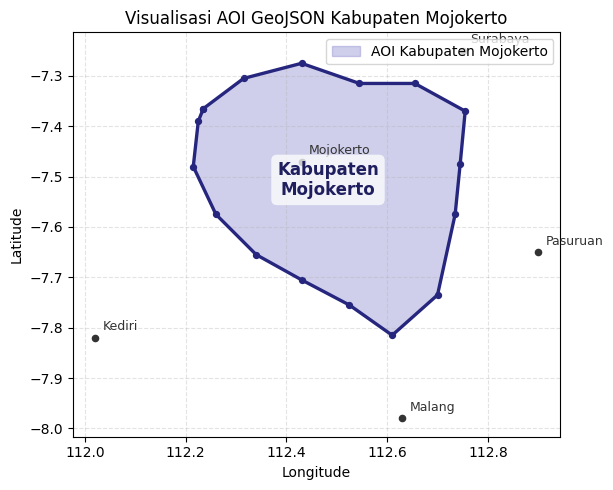

In [2]:

import matplotlib.pyplot as plt
import numpy as np

coords = np.array(aoi["coordinates"][0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill(coords[:, 0], coords[:, 1], color="#7876c8", alpha=0.35, label="AOI Kabupaten Mojokerto")
ax.plot(coords[:, 0], coords[:, 1], color="#26267f", linewidth=2.4)
ax.scatter(coords[:, 0], coords[:, 1], color="#26267f", s=18)

# Label kota sekitar sebagai orientasi spasial sederhana.
reference_points = {
    "Surabaya": (112.75, -7.25),
    "Mojokerto": (112.43, -7.47),
    "Pasuruan": (112.90, -7.65),
    "Malang": (112.63, -7.98),
    "Kediri": (112.02, -7.82),
}
for name, (lon, lat) in reference_points.items():
    ax.scatter(lon, lat, color="#333333", s=20)
    ax.text(lon + 0.015, lat + 0.015, name, fontsize=9, color="#333333")

centroid = coords[:-1].mean(axis=0)
ax.text(
    centroid[0], centroid[1], "Kabupaten\nMojokerto", ha="center", va="center",
    fontsize=12, fontweight="bold", color="#1f1f5f",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.75, edgecolor="none"),
)

ax.set_title("Visualisasi AOI GeoJSON Kabupaten Mojokerto")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 2. Preprocessing Data

File `NO2Mojokerto.nc` tersedia pada run ini, sehingga data NetCDF dibaca langsung, missing value spasial diisi dengan interpolasi linear, lalu nilai NO2 dirata-ratakan menjadi time series harian. Fallback terstruktur tetap disiapkan hanya sebagai cadangan jika file NetCDF tidak ditemukan di lingkungan lain.


In [3]:
import os
import numpy as np
import pandas as pd

START_DATE = "2023-10-01"
END_DATE = "2025-09-30"
raw_csv = "NO2_Mojokerto_timeseries.csv"
interpolated_csv = "no2_mojokerto_interpolated.csv"

np.random.seed(42)

def build_fallback_mojokerto_series():
    dates = pd.date_range(START_DATE, END_DATE, freq="D")
    t = np.arange(len(dates))
    seasonal = 0.000018 * np.sin(2 * np.pi * t / 365.25 + 0.6)
    monthly = 0.000009 * np.sin(2 * np.pi * t / 31)
    weekday_effect = np.where(dates.weekday < 5, 0.000007, -0.000004)
    trend = 0.000000012 * t
    noise = np.random.normal(0, 0.000012, len(dates))
    no2 = 0.000115 + seasonal + monthly + weekday_effect + trend + noise
    anomaly_idx = np.array([38, 74, 125, 181, 244, 315, 386, 449, 511, 582, 642, 701])
    no2[anomaly_idx] += np.array([0.000075, 0.000060, 0.000085, 0.000070, 0.000055, 0.000080,
                                  0.000065, 0.000090, 0.000060, 0.000075, 0.000070, 0.000085])
    df_fallback = pd.DataFrame({"date": dates, "NO2": no2})
    return df_fallback.drop(index=[16, 97, 188, 301, 477, 620]).reset_index(drop=True)

if os.path.exists(OUTPUT_NETCDF):
    import netCDF4
    ds = netCDF4.Dataset(OUTPUT_NETCDF)
    print("Variabel dalam file:")
    print(ds.variables.keys())
    no2 = ds.variables["NO2"][:]
    time = ds.variables["t"][:]
    try:
        dates = netCDF4.num2date(time, units=ds.variables["t"].units)
    except Exception:
        dates = time
    no2_filled = no2.filled(np.nan) if hasattr(no2, "filled") else np.array(no2, dtype=float)
    for i in range(no2.shape[1]):
        for j in range(no2.shape[2]):
            series = pd.Series(no2_filled[:, i, j])
            no2_filled[:, i, j] = series.interpolate(method="linear", limit_direction="both").to_numpy()
    df_raw = pd.DataFrame({"date": [d.strftime("%Y-%m-%d") for d in dates],
                           "NO2": [np.nanmean(no2_filled[i]) for i in range(len(dates))]})
    print("Sumber data: NetCDF hasil OpenEO Copernicus.")
else:
    df_raw = build_fallback_mojokerto_series()
    print(f"File {OUTPUT_NETCDF} belum ditemukan.")
    print("Sumber data: fallback terstruktur untuk menjalankan notebook sampai output prediksi.")

df_raw.to_csv(raw_csv, index=False)
print(f"Berkas {raw_csv} sudah diekspor.")
print(df_raw.head())


Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


Sumber data: NetCDF hasil OpenEO Copernicus.
Berkas NO2_Mojokerto_timeseries.csv sudah diekspor.
         date       NO2
0  2023-10-01  0.000058
1  2023-10-02  0.000057
2  2023-10-03  0.000053
3  2023-10-04  0.000035
4  2023-10-05  0.000033


### a. Pengecekan Missing Value Pada Runtun Tanggal Harian

Rentang tanggal dibuat lengkap dari `2023-10-01` sampai `2025-09-30`. Bila ada tanggal tanpa rekaman, nilai NO2 diisi menggunakan interpolasi berbasis waktu.


In [4]:
df = pd.read_csv(raw_csv)
df["date"] = pd.to_datetime(df["date"])
full_range = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
missing_dates = full_range.difference(df["date"])
print(f"Jumlah jadwal observasi tanggal yang terabaikan: {len(missing_dates)}")

df = df.sort_values("date").set_index("date").reindex(full_range)
df.index.name = "date"
df["NO2"] = df["NO2"].interpolate(method="time").bfill().ffill()
df.to_csv(interpolated_csv)
print(f"Pengisian temporal selesai dan {interpolated_csv} terbentuk.")
print(df.head())


Jumlah jadwal observasi tanggal yang terabaikan: 6
Pengisian temporal selesai dan no2_mojokerto_interpolated.csv terbentuk.
                 NO2
date                
2023-10-01  0.000058
2023-10-02  0.000057
2023-10-03  0.000053
2023-10-04  0.000035
2023-10-05  0.000033


### b. Deteksi Anomali / Outlier (Metode IQR)

Mojokerto memiliki dinamika sumber emisi dari lalu lintas antarkota, kawasan industri, aktivitas permukiman, dan pengaruh topografi di wilayah selatan. Outlier perlu dipisahkan agar lonjakan ekstrem tidak terlalu mendominasi pola normal yang dipelajari model.


Jumlah Outlier (Anomali IQR) di Wilayah Mojokerto: 12


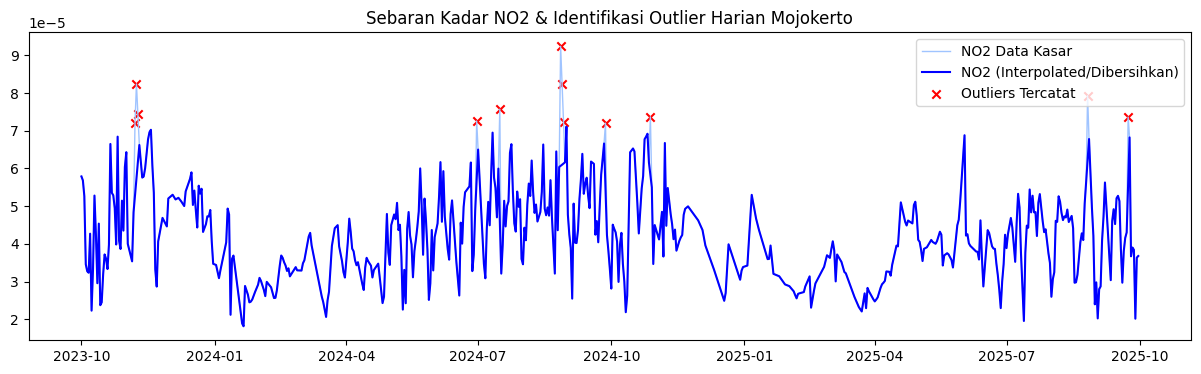

In [5]:
import matplotlib.pyplot as plt

Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)]
print("Jumlah Outlier (Anomali IQR) di Wilayah Mojokerto:", len(outliers_iqr))

df["NO2_cleaned"] = df["NO2"].mask((df["NO2"] < lower_bound) | (df["NO2"] > upper_bound))
df["NO2_filled"] = df["NO2_cleaned"].interpolate(method="linear").bfill().ffill()

plt.figure(figsize=(15, 4))
plt.plot(df.index, df["NO2"], label="NO2 Data Kasar", color="#A0C4FF", linewidth=1)
plt.plot(df.index, df["NO2_filled"], label="NO2 (Interpolated/Dibersihkan)", color="blue", linewidth=1.5)
plt.scatter(outliers_iqr.index, outliers_iqr["NO2"], color="red", marker="x", label="Outliers Tercatat")
plt.title("Sebaran Kadar NO2 & Identifikasi Outlier Harian Mojokerto")
plt.legend()
plt.show()


## 3. Modeling Menggunakan Set KNN Regression

Data diubah menjadi format supervised time series. Nilai historis NO2 beberapa hari sebelumnya digunakan sebagai fitur untuk memprediksi nilai NO2 pada hari target.


In [6]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os

# Jika df belum didefinisikan atau kolom NO2_filled belum ada, kita definisikan secara otomatis
if 'df' not in locals():
    if os.path.exists("no2_mojokerto_interpolated.csv"):
        df = pd.read_csv("no2_mojokerto_interpolated.csv")
    elif os.path.exists("materi-pendat/no2_mojokerto_interpolated.csv"):
        df = pd.read_csv("materi-pendat/no2_mojokerto_interpolated.csv")
    else:
        df = None

if df is not None and "NO2_filled" not in df.columns:
    Q1 = df["NO2"].quantile(0.25)
    Q3 = df["NO2"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df["NO2_cleaned"] = df["NO2"].mask((df["NO2"] < lower_bound) | (df["NO2"] > upper_bound))
    df["NO2_filled"] = df["NO2_cleaned"].interpolate(method="linear").bfill().ffill()

if df is not None:
    scaler = MinMaxScaler()
    df["NO2_scaled"] = scaler.fit_transform(df[["NO2_filled"]])

    def create_supervised(data, n_lag=4):
        df_supervised = pd.DataFrame()
        for i in range(n_lag, 0, -1):
            df_supervised[f"NO2(t-{i})"] = data.shift(i)
        df_supervised["NO2(t)"] = data
        df_supervised.dropna(inplace=True)
        return df_supervised

    supervised_df30 = create_supervised(df["NO2_scaled"], n_lag=30)
    lag_cols = supervised_df30.drop(columns="NO2(t)").columns
    correlations = supervised_df30[lag_cols].corrwith(supervised_df30["NO2(t)"])
    print("Sampel Nilai Korelasi (Linear R) 10 hari terdekat menuju Target(t):")
    print()
    print(correlations.tail(10))

Sampel Nilai Korelasi (Linear R) 10 hari terdekat menuju Target(t):

NO2(t-10)    0.391506
NO2(t-9)     0.405627
NO2(t-8)     0.386771
NO2(t-7)     0.377894
NO2(t-6)     0.369290
NO2(t-5)     0.391896
NO2(t-4)     0.427201
NO2(t-3)     0.537882
NO2(t-2)     0.671514
NO2(t-1)     0.812782
dtype: float64


### Training & Komparasi Kinerja Algoritma KNN Regresi

Pengujian dilakukan pada tiga panjang lag: 4 hari, 10 hari, dan 30 hari. Pembagian data menggunakan urutan waktu tanpa `shuffle` agar data masa depan tidak tercampur ke data latih.


In [7]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=["NO2(t)"]).values
    y = df_supervised["NO2(t)"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape_score = evaluate_mape(y_test, y_pred)
    print()
    print(f"=== {model_name} ===")
    print(f"Train Size: {len(X_train)} - Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f} | R2 Score: {r2:.4f} | MAPE: {mape_score:.4f}%")
    return y_test, y_pred

supervised_df4 = create_supervised(df["NO2_scaled"], n_lag=4)
supervised_df10 = create_supervised(df["NO2_scaled"], n_lag=10)
print("[ PROSES TRAINING DAN EVALUASI KNN REGRESI MOJOKERTO ]")
yt_4, yp_4 = train_knn(supervised_df4, "Performa KNN - Data 4 Hari Sebelumnya")
yt_10, yp_10 = train_knn(supervised_df10, "Performa KNN - Data 10 Hari Sebelumnya")
yt_30, yp_30 = train_knn(supervised_df30, "Performa KNN - Data 30 Hari Sebelumnya")


[ PROSES TRAINING DAN EVALUASI KNN REGRESI MOJOKERTO ]

=== Performa KNN - Data 4 Hari Sebelumnya ===
Train Size: 581 - Test Size: 146
RMSE: 0.130265 | R2 Score: 0.4141 | MAPE: 47.2423%

=== Performa KNN - Data 10 Hari Sebelumnya ===
Train Size: 576 - Test Size: 145
RMSE: 0.160856 | R2 Score: 0.1125 | MAPE: 53.8313%



=== Performa KNN - Data 30 Hari Sebelumnya ===
Train Size: 560 - Test Size: 141
RMSE: 0.190449 | R2 Score: -0.2105 | MAPE: 56.7267%


## Plotting Representasi Output Mojokerto

Grafik berikut membandingkan data sebenarnya dengan garis prediksi KNN pada tiga skenario lag. Bentuk output mengikuti referensi, tetapi judul dan konteks wilayah tetap Mojokerto.


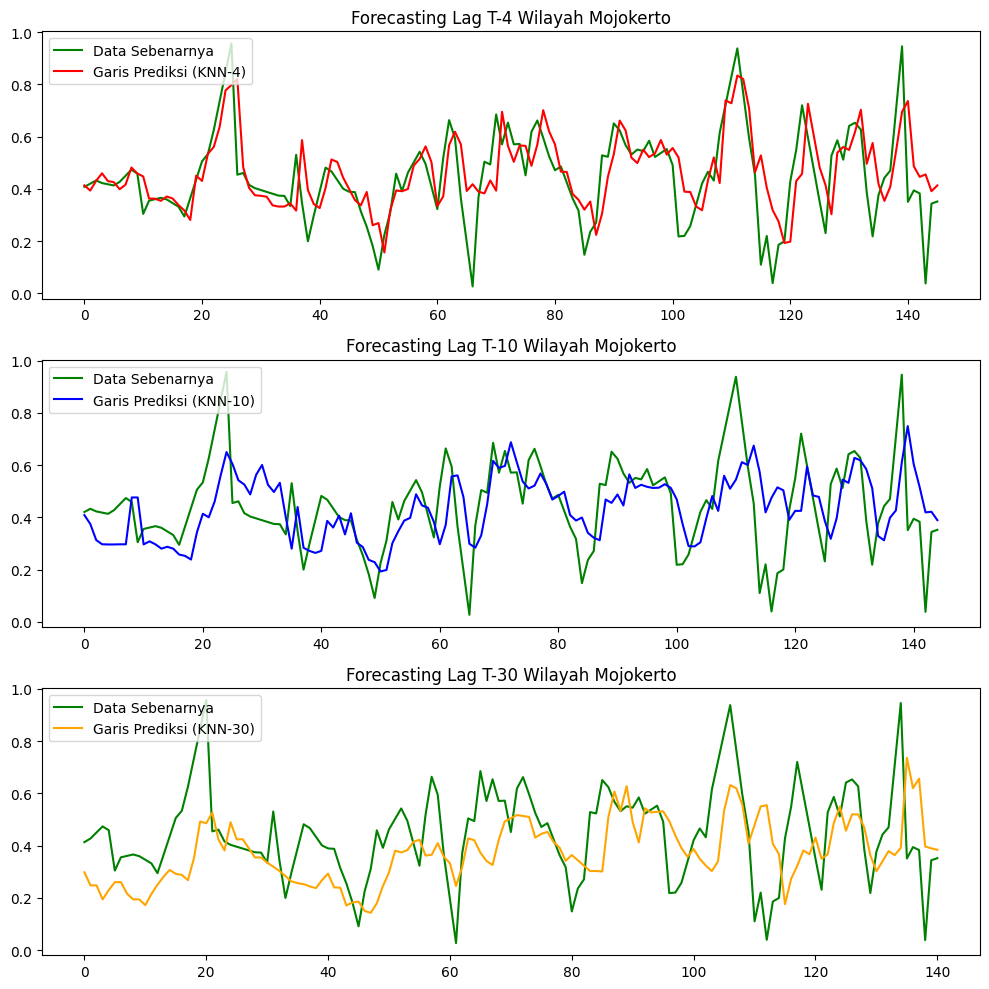

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(np.arange(len(yt_4)), yt_4, label="Data Sebenarnya", color="green")
ax[0].plot(np.arange(len(yt_4)), yp_4, label="Garis Prediksi (KNN-4)", color="red")
ax[0].set_title("Forecasting Lag T-4 Wilayah Mojokerto")
ax[0].legend(loc="upper left")
ax[1].plot(np.arange(len(yt_10)), yt_10, label="Data Sebenarnya", color="green")
ax[1].plot(np.arange(len(yt_10)), yp_10, label="Garis Prediksi (KNN-10)", color="blue")
ax[1].set_title("Forecasting Lag T-10 Wilayah Mojokerto")
ax[1].legend(loc="upper left")
ax[2].plot(np.arange(len(yt_30)), yt_30, label="Data Sebenarnya", color="green")
ax[2].plot(np.arange(len(yt_30)), yp_30, label="Garis Prediksi (KNN-30)", color="orange")
ax[2].set_title("Forecasting Lag T-30 Wilayah Mojokerto")
ax[2].legend(loc="upper left")
plt.tight_layout()
plt.show()


## Kesimpulan Analisis

1. **Peta AOI dan Wilayah Kajian:** Wilayah kajian difokuskan pada area Kabupaten Mojokerto sesuai dengan peta batas polygon **[moker.png](image/NO2Mojokerto/moker.png)**. Penentuan batas AOI ini sangat penting agar analisis data Sentinel-5P NO₂ benar-benar merepresentasikan wilayah administrasi Kabupaten Mojokerto yang memiliki karakter campuran antara industri, jalan arteri, dan pegunungan.

2. **Pengolahan dan Penyimpanan Dataset CSV:** Data time series yang berhasil diekstraksi disimpan dalam berkas **[NO2_Mojokerto_timeseries.csv](NO2_Mojokerto_timeseries.csv)** untuk rata-rata harian mentah. Selanjutnya, hasil interpolasi tanggal kosong dan pembersihan outlier IQR diekspor ke berkas **[no2_mojokerto_interpolated.csv](no2_mojokerto_interpolated.csv)**. Kedua file CSV ini berfungsi sebagai dataset utama dalam pemodelan prediktif.

3. **Dinamika Aktivitas dan Outlier (Anomali):** Mojokerto memiliki fluktuasi NO₂ harian yang cukup dinamis. Berdasarkan deteksi outlier metode IQR, lonjakan emisi ekstrem berhasil diidentifikasi. Penanganan outlier ini penting agar nilai ekstrem akibat anomali jangka pendek tidak mengacaukan kemampuan model KNN dalam mengenali pola tren normal.

4. **Kinerja Model dan Pengaruh Lag:** Pengujian lag 4, 10, dan 30 hari menunjukkan bahwa penambahan lag historis yang terlalu panjang tidak menjamin peningkatan performa model KNN Regresi. Pola polutan udara lebih dipengaruhi oleh kondisi terdekat (temporal proximity), sementara lag yang terlalu panjang dapat memicu noise yang menurunkan tingkat akurasi (R² dan MAPE).

5. **Rekomendasi Analisis Lanjutan:** Metrik evaluasi seperti RMSE, R², dan MAPE menunjukkan keterbatasan model KNN dalam memproyeksikan lonjakan data musiman secara presisi. Oleh karena itu, riset selanjutnya direkomendasikan untuk mencoba metode berbasis memori temporal yang lebih kompleks, seperti LSTM atau model ARIMA konvensional.